#### PCA on Socio-Economic Variables of Countries

In [681]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import cm
import warnings
np.random.seed(4702)
sns.set_style('whitegrid')
warnings.filterwarnings('ignore')

In [682]:
countries = pd.read_csv('countries/Country-data.csv', index_col = 'country')
countries

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
country,,,,,,,,,
Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200
...,...,...,...,...,...,...,...,...,...
Vanuatu,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970
Venezuela,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500
Vietnam,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310


In [683]:
n, p = countries.shape
print(f'Observations (Countries): {n}')
print(f'Variables: {p}')
print()

X = countries.values

# Sample Mean Vector
mu = (1/n) * X.T @ np.ones((n,1))
print('Mean Vector: ')
print(pd.DataFrame(mu, index = countries.columns))

# Sample Covariance Matrix (S)
Q = np.ones((n, 1)) @ mu.T
S = (1/(n-1)) * (X - Q).T @  (X - Q)

print('\nCovariance Matrix:')
pd.DataFrame(S, index = countries.columns, columns = countries.columns)

Observations (Countries): 167
Variables: 9

Mean Vector: 
                       0
child_mort     38.270060
exports        41.108976
health          6.815689
imports        46.890215
income      17144.688623
inflation       7.781832
life_expec     70.555689
total_fer       2.947964
gdpp        12964.155689

Covariance Matrix:


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
child_mort,1626.422713,-351.651128,-22.199943,-124.201982,-4.076360e+05,122.893627,-318.008262,51.801162,-3.570463e+05
exports,-351.651128,751.418298,-8.614534,489.350622,2.730946e+05,-31.090078,77.110598,-13.279671,2.103785e+05
health,-22.199943,-8.614534,7.545116,6.365141,6.861669e+03,-7.415093,5.146808,-0.817828,1.741797e+04
imports,-124.201982,489.350622,6.365141,586.104198,5.712872e+04,-63.208898,11.710284,-5.829066,5.125005e+04
income,-407635.982270,273094.598023,6861.669071,57128.721588,3.716439e+08,-30110.122438,104916.785517,-14645.727927,3.164430e+08
inflation,122.893627,-31.090078,-7.415093,-63.208898,-3.011012e+04,111.739781,-22.533965,5.071509,-4.294042e+04
life_expec,-318.008262,77.110598,5.146808,11.710284,1.049168e+05,-22.533965,79.088507,-10.243585,9.781472e+04
total_fer,51.801162,-13.279671,-0.817828,-5.829066,-1.464573e+04,5.071509,-10.243585,2.291734,-1.262233e+04
gdpp,-357046.306154,210378.470377,17417.971217,51250.050217,3.164430e+08,-42940.421636,97814.722603,-12622.333657,3.359414e+08


##### Eigen-Decomposition of S

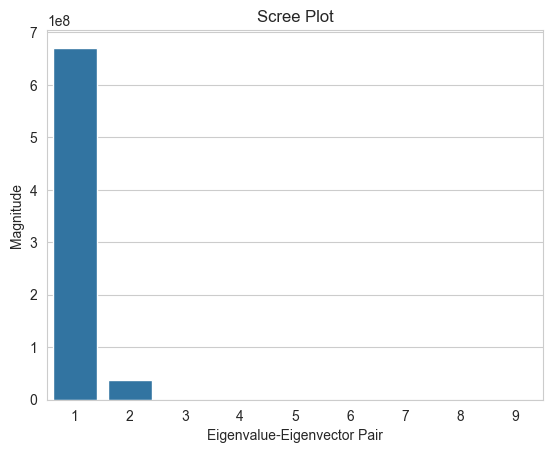

In [ ]:
cov_eigen_values, cov_eigen_vectors = np.linalg.eig(S)

sorted_indices = np.argsort(cov_eigen_values)[::-1]
cov_eigen_values = cov_eigen_values[sorted_indices]
cov_eigen_vectors = cov_eigen_vectors[:, sorted_indices]

# Scree plot will show how much variance is captured by each eigenvector-eigenvalue pair
sns.barplot(x = range(1,10), y = cov_eigen_values)
plt.title('Scree Plot')
plt.xlabel('Eigenvalue-Eigenvector Pairs')
plt.ylabel('Magnitude')
plt.show()

In [685]:
# Proportions of Total Variance attributed to Principal components

total_variance = sum(cov_eigen_values)
total_variance

explained_variance = 100 * cov_eigen_values / total_variance

for i in range(p):
    print(f'PC{i+1} : {explained_variance[i]:.5f}%')

print(f'\nPC1 & PC2 Proportion of Explained Variance: {explained_variance[0] + explained_variance[1]:.5f}%')

PC1 : 94.79231%
PC2 : 5.20735%
PC3 : 0.00018%
PC4 : 0.00014%
PC5 : 0.00002%
PC6 : 0.00001%
PC7 : 0.00000%
PC8 : 0.00000%
PC9 : 0.00000%

PC1 & PC2 Proportion of Explained Variance: 99.99965%


Thus we can project our data onto the 2 Principal Components without losing signaificant variance within the data.

In [686]:
Y = X @ cov_eigen_vectors[:, 0:2]

In [687]:
# Linear Combination of PC1 & PC2

for i in range(2):
    print(f'PC{i+1} = ', end = '')
    for j in range(p):
        print(f'{cov_eigen_vectors[j, i]:.4f} * X{j+1} ', end = '')
        if (j != p - 1):
            print('+ ', end = '')
    print()

PC1 = 0.0008 * X1 + -0.0005 * X2 + -0.0000 * X3 + -0.0001 * X4 + -0.7267 * X5 + 0.0001 * X6 + -0.0002 * X7 + 0.0000 * X8 + -0.6869 * X9 
PC2 = -0.0006 * X1 + 0.0009 * X2 + -0.0002 * X3 + 0.0001 * X4 + 0.6869 * X5 + 0.0003 * X6 + 0.0000 * X7 + -0.0000 * X8 + -0.7267 * X9 


In [688]:
descriptions = pd.read_csv('countries/data-dictionary.csv')

print('Variable Descriptions')
for i in range(1, descriptions.shape[0]):
    print(f'X{i} {descriptions.iloc[i, 0]} : {descriptions.iloc[i, 1]}')

Variable Descriptions
X1 child_mort : Death of children under 5 years of age per 1000 live births
X2 exports : Exports of goods and services. Given as %age of the Total GDP
X3 health : Total health spending as %age of Total GDP
X4 imports : Imports of goods and services. Given as %age of the Total GDP
X5 Income : Net income per person
X6 Inflation : The measurement of the annual growth rate of the Total GDP
X7 life_expec : The average number of years a new born child would live if the current mortality patterns are to remain the same
X8 total_fer : The number of children that would be born to each woman if the current age-fertility rates remain the same.
X9 gdpp : The GDP per capita. Calculated as the Total GDP divided by the total population.


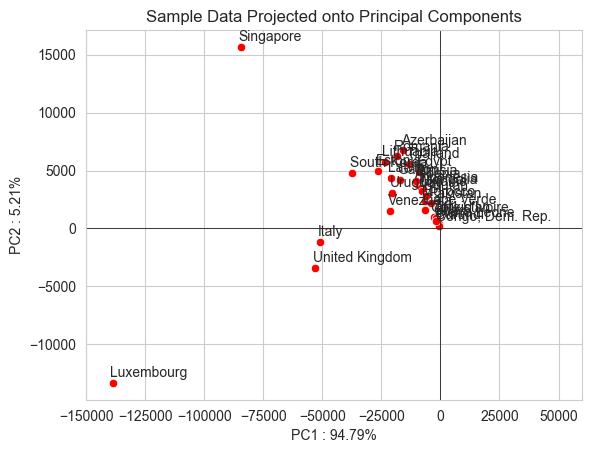

In [689]:
pca_countries = pd.DataFrame(Y, columns = ['PC1', 'PC2'])
pca_countries['COUNTRY'] = countries.index
pca_countries = pca_countries[['COUNTRY', 'PC1', 'PC2']]
sample = pca_countries.sample(n = 30)

sns.scatterplot(x = sample.iloc[:, 1], y = sample.iloc[:, 2], c = 'r')
plt.title('Sample Data Projected onto Principal Components')
plt.axhline(y = 0, c = 'k', linewidth = 0.5)
plt.axvline(x = 0, c = 'k', linewidth = 0.5)
plt.xlim((-150000, 60000))
plt.xlabel(f'PC1 : {explained_variance[0]:.2f}%')
plt.ylabel(f'PC2 : {explained_variance[1]:.2f}%')

for i in range(30):
    text = sample.iloc[i, 0]
    plt.text(s = text, x = sample.iloc[i, 1] - 1000, y = sample.iloc[i, 2] + 500, size = 10)

plt.show()

In [690]:
# This analysis is highly inaccurate because both principle components are made up mostly of
# income and gdp/capita which are both on higher scales relative to other variables.

# Because of this we must standardize our variables and use the eigen-decomposition of the correlation matrix.

#### Repetition of PCA using Correlation Matrix

In [691]:
# Correlation Matrix (S)

V = np.sqrt(np.diag(np.diag(S)))
V_inv = np.linalg.inv(V)

R = V_inv @ S @ V_inv
pd.DataFrame(R, columns = countries.columns, index = countries.columns)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
child_mort,1.000000,-0.318093,-0.200402,-0.127211,-0.524315,0.288276,-0.886676,0.848478,-0.483032
exports,-0.318093,1.000000,-0.114408,0.737381,0.516784,-0.107294,0.316313,-0.320011,0.418725
health,-0.200402,-0.114408,1.000000,0.095717,0.129579,-0.255376,0.210692,-0.196674,0.345966
imports,-0.127211,0.737381,0.095717,1.000000,0.122406,-0.246994,0.054391,-0.159048,0.115498
income,-0.524315,0.516784,0.129579,0.122406,1.000000,-0.147756,0.611962,-0.501840,0.895571
inflation,0.288276,-0.107294,-0.255376,-0.246994,-0.147756,1.000000,-0.239705,0.316921,-0.221631
life_expec,-0.886676,0.316313,0.210692,0.054391,0.611962,-0.239705,1.000000,-0.760875,0.600089
total_fer,0.848478,-0.320011,-0.196674,-0.159048,-0.501840,0.316921,-0.760875,1.000000,-0.454910
gdpp,-0.483032,0.418725,0.345966,0.115498,0.895571,-0.221631,0.600089,-0.454910,1.000000


In [692]:
# Standardized Data Matrix

Z = (X - Q) @ V_inv
pd.DataFrame(Z, columns = countries.columns)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.287660,-1.134867,0.278251,-0.082208,-0.805822,0.156864,-1.614237,1.897176,-0.677143
1,-0.537333,-0.478220,-0.096725,0.070624,-0.374243,-0.311411,0.645924,-0.857394,-0.484167
2,-0.272015,-0.098824,-0.963176,-0.639838,-0.220182,0.786908,0.668413,-0.038289,-0.463980
3,2.001787,0.773056,-1.443729,-0.164820,-0.583289,1.382894,-1.175698,2.121770,-0.514720
4,-0.693548,0.160186,-0.286034,0.496076,0.101427,-0.599944,0.702147,-0.540321,-0.041692
...,...,...,...,...,...,...,...,...,...
162,-0.224902,0.200315,-0.569997,0.239979,-0.736313,-0.488315,-0.849606,0.364658,-0.545273
163,-0.524935,-0.459980,-0.693776,-1.209860,-0.033442,3.606020,0.544723,-0.315728,0.029235
164,-0.371199,1.126916,0.008851,1.375892,-0.656429,0.408503,0.286097,-0.659224,-0.635842
165,0.447072,-0.405259,-0.595481,-0.515920,-0.656948,1.496416,-0.343599,1.137523,-0.635842


##### Eigen-Decomposition of R

In [693]:
corr_eigen_values, corr_eigen_vectors = np.linalg.eig(R)

# Sorting Eigen-Decomposition in order of greatest variance (eigenvalue)
sorted_indices = np.argsort(corr_eigen_values)[::-1]
corr_eigen_values = corr_eigen_values[sorted_indices]
corr_eigen_vectors = corr_eigen_vectors[:, sorted_indices]

corr_eigen_values

array([4.13565658, 1.54634631, 1.1703833 , 0.99478456, 0.66061903,
       0.22358112, 0.11343874, 0.08831536, 0.06687501])

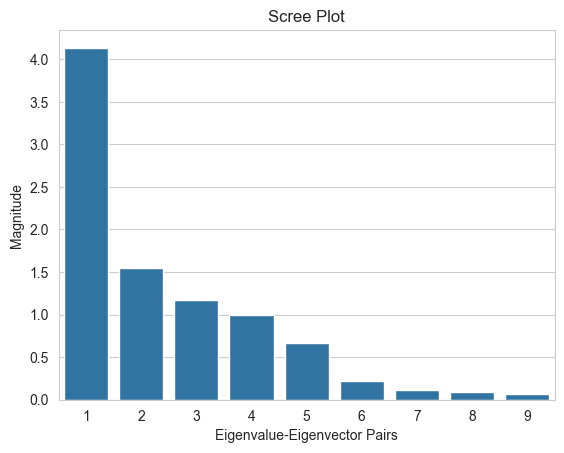

In [694]:
sns.barplot(x = range(1,10), y = corr_eigen_values)
plt.title('Scree Plot')
plt.xlabel('Eigenvalue-Eigenvector Pairs')
plt.ylabel('Magnitude')
plt.show()

In [695]:
total_variance = sum(corr_eigen_values)
total_variance

for i in range(p):
    print(f'PC{i+1} : {100 * corr_eigen_values[i] / total_variance:.5f}%')

explained_variance = 100 * corr_eigen_values / total_variance
print(f'\nPC1, PC2 & PC3 % of Explained Variance: {sum(explained_variance[0:3]):.5f}%')
print(f'PC1, PC2 & PC3 % of lost variance: {100 - sum(explained_variance[0:3]):.5f}%\n')

PC1 : 45.95174%
PC2 : 17.18163%
PC3 : 13.00426%
PC4 : 11.05316%
PC5 : 7.34021%
PC6 : 2.48423%
PC7 : 1.26043%
PC8 : 0.98128%
PC9 : 0.74306%

PC1, PC2 & PC3 % of Explained Variance: 76.13762%
PC1, PC2 & PC3 % of lost variance: 23.86238%



In [696]:
# PCs as linear combinations

for i in range(3):
    print(f'PC{i+1} = ', end = '')
    for j in range(p):
        print(f'{corr_eigen_vectors[j, i]:.4f} * X{j+1} ', end = '')
        if (j != p - 1):
            print('+ ', end = '')
    print()

PC1 = 0.4195 * X1 + -0.2839 * X2 + -0.1508 * X3 + -0.1615 * X4 + -0.3984 * X5 + 0.1932 * X6 + -0.4258 * X7 + 0.4037 * X8 + -0.3926 * X9 
PC2 = -0.1929 * X1 + -0.6132 * X2 + 0.2431 * X3 + -0.6718 * X4 + -0.0225 * X5 + 0.0084 * X6 + 0.2227 * X7 + -0.1552 * X8 + 0.0460 * X9 
PC3 = 0.0295 * X1 + -0.1448 * X2 + 0.5966 * X3 + 0.2999 * X4 + -0.3015 * X5 + -0.6425 * X6 + -0.1139 * X7 + -0.0195 * X8 + -0.1230 * X9 


***PC1 Analysis:***   

X7 (Life Expectancy) : $ -0.4258 $  
X8 (Total Fertility) : $ 0.4037 $   
X1 (Child Mortality) : $ 0.4195 $   
X9 (GDP per Capita)  : $ -0.3926 $  
X5 (Income)          : $ -0.3984 $  

We can interpret PC1 as a Development Index since weighting is focused on developmental factors.    
Countries high in PC1 are likely developing countries with lower income, higher birth rates and higher child mortalities.

***PC2 Analysis:***   

X2 (Imports) : $ -0.6132 $  
X4 (Exports) : $ -0.6718 $  

We can interpret PC2 as a Global Trade Volume Index since weights are focused on imports and exports.   
Countries high in PC2 are likely to be less active in global markets while countries low in PC2 are more engaged in global trade.

***PC3 Analysis:***   

X3 (Health Spending) : $ 0.5966 $  
X6 (Inflation)       : $ -0.6132 $  

Finally, we can interpret PC3 as the trade-off between health spending and inflation.   
Countries high in PC3 are likely to have economies with governments spending relatively more on healthcare while keeping inflation in check.    
Countries low in PC3 are likely to have economies that do not spend on healthcare but struggle to keep prices from rising.

In [697]:
Y = Z @ corr_eigen_vectors[:, 0:3]

In [698]:
pca_countries = pd.DataFrame(Y, columns = ['PC1', 'PC2', 'PC3'])
pca_countries['COUNTRY'] = countries.index
pca_countries = pca_countries[['COUNTRY', 'PC1', 'PC2', 'PC3']]
pca_countries

,COUNTRY,PC1,PC2,PC3
0,Afghanistan,2.904290,-0.095334,0.715965
1,Albania,-0.428622,0.586392,0.332486
2,Algeria,0.284370,0.453810,-1.217842
3,Angola,2.923630,-1.690471,-1.520471
4,Antigua and Barbuda,-1.030477,-0.136249,0.225044
...,...,...,...,...
162,Vanuatu,0.818170,-0.637652,0.388754
163,Venezuela,0.549383,1.230186,-3.092051
164,Vietnam,-0.497030,-1.386574,0.237811
165,Yemen,1.881792,0.109125,-1.106424


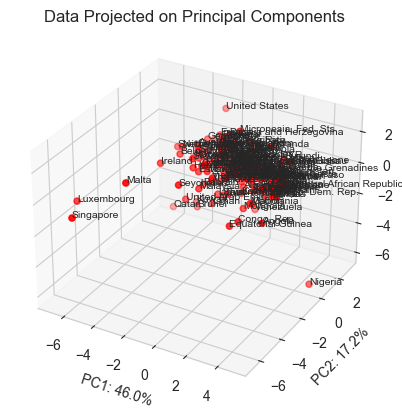

In [699]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.set_title('Data Projected on Principal Components')
ax.scatter(xs = Y[:, 0], ys = Y[:, 1], zs = Y[:, 2], c = 'r')
ax.set_xlabel(f'PC1: {explained_variance[0]:.1f}%')
ax.set_ylabel(f'PC2: {explained_variance[1]:.1f}%')
ax.set_zlabel(f'PC3: {explained_variance[2]:.1f}%')

for i in range(n):
    text = countries.index[i]
    ax.text(Y[i, 0], Y[i, 1], Y[i, 2], text, size = 7.5)

plt.show()

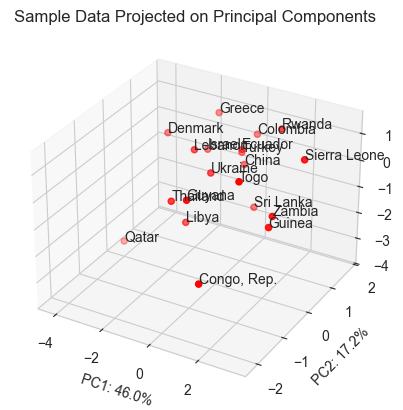

In [700]:
sample = pca_countries.sample(n = 20)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.set_title('Sample Data Projected on Principal Components')
ax.scatter(xs = sample.iloc[:, 1], ys = sample.iloc[:, 2], zs = sample.iloc[:, 3], c = 'r')
ax.set_xlabel(f'PC1: {explained_variance[0]:.1f}%')
ax.set_ylabel(f'PC2: {explained_variance[1]:.1f}%')
ax.set_zlabel(f'PC3: {explained_variance[2]:.1f}%')

for i in range(20):
    text = sample.iloc[i, 0]
    ax.text(sample.iloc[i, 1], sample.iloc[i, 2], sample.iloc[i, 3], text, size = 10)

plt.show()